# Vidarbha — CHF Composite Index Backtest & Nowcast (v8 — 23-year calibration)

## Key changes from v5/v6
1. **Composite Crop Health Factor (CHF)** replaces binary rule-based triggers — entropy-weighted combination of satellite features (per [Murthy et al. 2021, West Bengal PMFBY](https://doi.org/10.1080/19475705.2021.2025155))
2. **Phenological sub-windows** — separate features for Jun-Jul / Aug-Sep / Oct instead of fixed kharif average (per [Afshar et al. 2021, *Remote Sensing*](https://doi.org/10.3390/rs13050924))
3. **Yield-calibrated thresholds** — strike/exit set against APY yield anomalies, not internal percentiles
4. **FAPAR added** — MODIS MCD15A3H photosynthetic activity, a more direct crop productivity proxy than NDVI alone

## Changes from v4 (see `Trigger_Threshold_Review_Notes.md`)

1. **IMD standards** replace arbitrary p70 for `cumRain_mm` (>120% LPA) and `heavy_rain_days` (>64.5mm/day IMD definition)
2. **VHI relabelled** as internal percentile — not Kogan's international scale (season-mean aggregation prevents direct comparison)
3. **Heat trigger dropped** — `gdd_surplus` (CV=37%) and `lst_anom_augsep` (CV=832%) are statistically unstable with 4 years of baseline
4. **2-of-3 AND logic** within each peril replaces pure OR (fixes the 75% fire rate problem)
5. **WBCIS tiered payouts** replace binary triggers — Strike/Exit structure per the official Indian weather-index insurance guidelines
6. **APY yield validation** — 24 years of district-level cotton/soybean yields cross-checked against satellite signals
7. **EOS-06 ISRO NDVI** added to nowcast section

## Conceptual framing

```
Satellite data → IMD/agronomic thresholds → Tiered payout (WBCIS formula) ────┐
                                                                                ▼
PMFBY payouts ──────────────────────────────────────────────────→  Comparison benchmark
APY district yields ───────────────────────────────────────────→  Independent validation
```

## Trigger architecture (revised)
```
DROUGHT : ≥2 of {VHI < p30, drySpellDays > p70, dry_spell_julaug > p70}
FLOOD   : ≥2 of {cumRain > 120% LPA, heavy_rain_days ≥ 3 (IMD heavy-rain count), sm_wet_days > p70}
─────────────────────────────────────────────────────────────────
PAYOUT  : ANY peril fires → tiered payout (Strike1/Strike2/Exit per WBCIS)
```
Heat trigger removed from v5 — will return when baseline extends to 10+ years.

## Parts
- **A** — APY yield validation: does our satellite signal match actual crop outcomes?
- **B** — Satellite distributions with revised thresholds
- **C** — Trigger implementation (2-of-3 AND, tiered payout)
- **D** — Backtest vs PMFBY
- **E** — Nowcast 2025 (with EOS-06 ISRO data)

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from scipy.stats import spearmanr, entropy as scipy_entropy
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
OUT = Path('./vidarbha_outputs')
OUT.mkdir(exist_ok=True)

BACKTEST_YEARS = list(range(2003, 2025))  # 2003-2024: 22 years
NOWCAST_YEAR   = 2025
PMFBY_YEARS    = list(range(2018, 2025))  # PMFBY only available 2018-2024

DISTRICT_LPA = {
    'Yavatmal':   950.0,
    'Amravati':   850.0,
    'Chandrapur': 1100.0,
    'Wardha':     860.0,
}

SUM_INSURED_PER_HA = 40000
PMFBY_LOSS_THRESHOLD = 0.10

print('v8 config loaded.')
print(f'Backtest: {BACKTEST_YEARS[0]}-{BACKTEST_YEARS[-1]} ({len(BACKTEST_YEARS)} years)')
print(f'PMFBY comparison: {PMFBY_YEARS[0]}-{PMFBY_YEARS[-1]} ({len(PMFBY_YEARS)} years)')

v8 config loaded.
Backtest: 2003-2024 (22 years)
PMFBY comparison: 2018-2024 (7 years)


In [2]:
# ── Load 23-year unified dataset ──────────────────────────────────────────────
df = pd.read_csv('data/processed/all_districts_23yr_features.csv')
df['revenue_circle'] = df['revenue_circle'].str.strip()

# Load corrected APY from DES official data (18 crops, all 4 districts)
apy_raw = pd.read_csv('data/processed/apy_district_yields_v2.csv')
apy_raw = apy_raw.dropna(subset=['cotton_lint_yield_kg_ha','soybean_yield_kg_ha'], how='all')

# Compute per-district yield z-scores for each crop
crop_yield_cols = [c for c in apy_raw.columns if c.endswith('_yield_kg_ha')]
for crop_col in crop_yield_cols:
    z_col = crop_col.replace('_yield_kg_ha', '_z')
    for dist in apy_raw['district'].unique():
        full = apy_raw[apy_raw['district']==dist][crop_col].dropna()
        mu, sigma = full.mean(), full.std()
        mask = apy_raw['district'] == dist
        apy_raw.loc[mask, z_col] = (apy_raw.loc[mask, crop_col] - mu) / sigma if sigma > 0 else 0

# Multi-crop composite stress: average z-scores across all available crops
# Weighted by planted area where available
z_cols = [c for c in apy_raw.columns if c.endswith('_z')]
apy_raw['crop_stress_z'] = apy_raw[z_cols].mean(axis=1)

# Also keep soy+cotton only version for comparison
apy_raw['crop_stress_z_2crop'] = apy_raw[['soybean_z','cotton_lint_z']].mean(axis=1)

print(f'APY v2 (DES official): {len(apy_raw)} district-years')
print(f'Crops with z-scores: {len(z_cols)} ({", ".join(c.replace("_z","") for c in z_cols)})')
print(f'Using multi-crop composite stress (mean of {len(z_cols)} crop z-scores)')

bt = df[df['year'].isin(BACKTEST_YEARS)].copy()
nc = df[df['year'] == NOWCAST_YEAR].copy()

bt['pmfby_stress'] = bt['rate_total'] > PMFBY_LOSS_THRESHOLD

# APY overlap check
apy_bt_years = sorted(set(BACKTEST_YEARS) & set(apy_raw['year'].unique()))
n_calib = len(apy_bt_years) * df['district'].nunique()

print(f'23-year dataset: {df.shape[0]} rows × {df.shape[1]} columns')
print(f'Years: {df["year"].min()}-{df["year"].max()} | RCs: {df["revenue_circle"].nunique()}')
print(f'Backtest: {len(bt)} rows ({BACKTEST_YEARS[0]}-{BACKTEST_YEARS[-1]})')
print(f'Nowcast: {len(nc)} rows ({NOWCAST_YEAR})')
print(f'APY calibration points: {n_calib} district-years ({len(apy_bt_years)} years × {df["district"].nunique()} districts)')
print(f'  Includes droughts: 2004, 2009, 2012, 2015, 2018')
print(f'CHF features: FAPAR={bt["FAPAR_mean"].notna().sum()}/{len(bt)}, '
      f'NDVI_augsep={bt["NDVI_augsep"].notna().sum()}/{len(bt)}, '
      f'rain_augsep={bt["rain_augsep_mm"].notna().sum()}/{len(bt)}')

APY v2 (DES official): 92 district-years
Crops with z-scores: 9 (soybean, cotton_lint, arhar_tur, groundnut, jowar, maize, moonggreen_gram, rice, urad)
Using multi-crop composite stress (mean of 9 crop z-scores)
23-year dataset: 6371 rows × 70 columns
Years: 2003-2025 | RCs: 271
Backtest: 6094 rows (2003-2024)
Nowcast: 277 rows (2025)
APY calibration points: 80 district-years (20 years × 4 districts)
  Includes droughts: 2004, 2009, 2012, 2015, 2018
CHF features: FAPAR=6094/6094, NDVI_augsep=6094/6094, rain_augsep=6094/6094


## A · CHF Composite Index — Entropy-Weighted Crop Health Factor

Following [Murthy et al. (2021)](https://doi.org/10.1080/19475705.2021.2025155) — the West Bengal CHF that replaced yield data in PMFBY:

1. Select sub-indicators (NDVI, FAPAR, SM, SAR, rainfall) per phenological window
2. Normalize each to [0, 1] using min-max (higher = healthier crop)
3. Compute entropy-based weights (features with more discriminating power get higher weight)
4. CHF = weighted sum ∈ [0, 1]; deviation from historical mean = stress signal
5. Calibrate trigger threshold against APY yield z-scores

In [3]:
# ── Step 1: Select CHF sub-indicators ─────────────────────────────────────────
# Vegetation health (higher = healthier)
# Moisture/water (direction depends on context — we orient all so higher = healthier)
# Rainfall sub-windows (mid-range is best, but for drought detection: higher = healthier)

CHF_COMPONENTS = {
    # (column, direction) — 'positive' means higher raw = healthier crop
    'NDVI_junjul':       'positive',
    'NDVI_augsep':       'positive',    # flowering stage NDVI — most critical
    'NDVI_oct':          'positive',
    'FAPAR_mean':        'positive',    # photosynthetic activity
    'SM_augsep':         'positive',    # soil moisture during flowering
    'SAR_VH_augsep_dB':  'positive',   # SAR backscatter (higher = denser crop canopy)
    'rain_augsep_mm':    'positive',    # rainfall during critical stage
    'rain_junjul_mm':    'positive',    # sowing-stage rainfall
}

# ── Step 2: Min-max normalize to [0, 1] ──────────────────────────────────────
# Using backtest data to set normalization bounds (nowcast gets same scaling)
norm_params = {}
for col, direction in CHF_COMPONENTS.items():
    vals = bt[col].dropna()
    lo, hi = vals.quantile(0.02), vals.quantile(0.98)  # robust to outliers
    norm_params[col] = (lo, hi, direction)

def normalize_chf(d, params):
    d = d.copy()
    for col, (lo, hi, direction) in params.items():
        normed = (d[col] - lo) / (hi - lo)
        normed = normed.clip(0, 1)
        if direction == 'negative':
            normed = 1 - normed
        d[f'{col}_norm'] = normed
    return d

bt = normalize_chf(bt, norm_params)
nc = normalize_chf(nc, norm_params)

norm_cols = [f'{c}_norm' for c in CHF_COMPONENTS]

print('=== CHF SUB-INDICATOR NORMALIZATION ===')
for col, (lo, hi, direction) in norm_params.items():
    print(f'  {col:25s}: [{lo:.3f}, {hi:.3f}]  direction={direction}')

# ── Step 3: Entropy-based weights ─────────────────────────────────────────────
# Entropy method: features with more variation (more discriminating power) get higher weight
# Following Murthy et al. (2021) and Shannon entropy approach

def compute_entropy_weights(data, cols):
    """Compute entropy-based weights for normalized [0,1] indicators."""
    D = data[cols].dropna()
    n = len(D)
    k = 1.0 / np.log(n)  # normalization constant

    weights = {}
    for col in cols:
        p = D[col] / D[col].sum()  # proportion
        p = p.replace(0, 1e-10)    # avoid log(0)
        e = -k * (p * np.log(p)).sum()  # entropy
        d = 1 - e  # diversification (dispersion)
        weights[col] = d

    # Normalize weights to sum to 1
    total = sum(weights.values())
    for col in weights:
        weights[col] /= total

    return weights

entropy_weights = compute_entropy_weights(bt, norm_cols)

print()
print('=== ENTROPY WEIGHTS ===')
print('(Higher weight = feature has more discriminating power across RC-years)')
for col, w in sorted(entropy_weights.items(), key=lambda x: -x[1]):
    raw_col = col.replace('_norm', '')
    print(f'  {raw_col:25s}: w={w:.3f}  ({w*100:.1f}%)')

# ── Step 4: Compute CHF ──────────────────────────────────────────────────────
def compute_chf(d, weights, norm_cols):
    d = d.copy()
    chf = np.zeros(len(d))
    for col, w in weights.items():
        chf += d[col].fillna(0.5) * w  # fill missing with neutral 0.5
    d['CHF'] = chf
    return d

bt = compute_chf(bt, entropy_weights, norm_cols)
nc = compute_chf(nc, entropy_weights, norm_cols)

# CHF anomaly: deviation from per-district historical mean
for dist in bt['district'].unique():
    dist_mean = bt[bt['district']==dist]['CHF'].mean()
    bt.loc[bt['district']==dist, 'CHF_mean_dist'] = dist_mean
    bt.loc[bt['district']==dist, 'CHF_anom'] = bt.loc[bt['district']==dist, 'CHF'] - dist_mean
    nc.loc[nc['district']==dist, 'CHF_mean_dist'] = dist_mean
    nc.loc[nc['district']==dist, 'CHF_anom'] = nc.loc[nc['district']==dist, 'CHF'] - dist_mean

print()
print('=== CHF DISTRIBUTION ===')
print(f'  Backtest: mean={bt["CHF"].mean():.3f}  std={bt["CHF"].std():.3f}  '
      f'min={bt["CHF"].min():.3f}  max={bt["CHF"].max():.3f}')
for dist in sorted(bt['district'].unique()):
    s = bt[bt['district']==dist]
    print(f'    {dist:12s}: mean={s["CHF"].mean():.3f}  std={s["CHF"].std():.3f}')
print()
yr_chf = bt.groupby('year')['CHF'].mean()
print('CHF by year (highlight droughts):')
for yr in BACKTEST_YEARS:
    apy_yr = apy_raw[apy_raw['year']==yr]['crop_stress_z'].mean()
    tag = ''
    if not np.isnan(apy_yr):
        if apy_yr < -0.5: tag = ' ← BAD'
        elif apy_yr > 0.5: tag = ' ← GOOD'
    chf_val = yr_chf.get(yr, float('nan'))
    if not np.isnan(chf_val):
        print(f'  {yr}: CHF={chf_val:.3f}  APY_z={apy_yr:+.2f}{tag}' if not np.isnan(apy_yr)
              else f'  {yr}: CHF={chf_val:.3f}  APY_z=N/A')

=== CHF SUB-INDICATOR NORMALIZATION ===
  NDVI_junjul              : [0.151, 0.541]  direction=positive
  NDVI_augsep              : [0.425, 0.753]  direction=positive
  NDVI_oct                 : [0.475, 0.784]  direction=positive
  FAPAR_mean               : [0.248, 0.431]  direction=positive
  SM_augsep                : [0.278, 0.419]  direction=positive
  SAR_VH_augsep_dB         : [-17.040, -13.644]  direction=positive
  rain_augsep_mm           : [254.102, 874.100]  direction=positive
  rain_junjul_mm           : [305.141, 913.068]  direction=positive

=== ENTROPY WEIGHTS ===
(Higher weight = feature has more discriminating power across RC-years)
  NDVI_junjul              : w=0.191  (19.1%)
  rain_augsep_mm           : w=0.161  (16.1%)
  rain_junjul_mm           : w=0.132  (13.2%)
  NDVI_augsep              : w=0.123  (12.3%)
  SM_augsep                : w=0.110  (11.0%)
  FAPAR_mean               : w=0.104  (10.4%)
  SAR_VH_augsep_dB         : w=0.097  (9.7%)
  NDVI_oct        

## B · Yield-Calibrated Threshold — CHF vs APY

Instead of arbitrary percentiles, set the trigger where CHF predicts actual yield drops.

=== CHF CORRELATION WITH GROUND TRUTH ===


District-year observations: 80

CHF vs APY crop_stress_z:  ρ=+0.138  p=0.2215
CHF vs PMFBY rate_total:   ρ=+0.066  p=0.8008

For comparison:
  v7 (8yr):  ρ≈-0.10  (28 calibration points)
  v8 (23yr): ρ=+0.138  (80 calibration points)

Bad yield district-years (z < -0.5): 17/80

Optimal CHF threshold (max F1 on APY bad years):
  Strike = 0.435  (CHF below this → trigger)
  F1 = 0.43
  Exit  = 0.449  (max payout below this)

FLOOD: Rain_augsep > 60% of kharif LPA (per-district IMD excess)
  Yavatmal    : augsep_normal=570mm  excess>684mm
  Amravati    : augsep_normal=510mm  excess>612mm
  Chandrapur  : augsep_normal=660mm  excess>792mm
  Wardha      : augsep_normal=516mm  excess>619mm


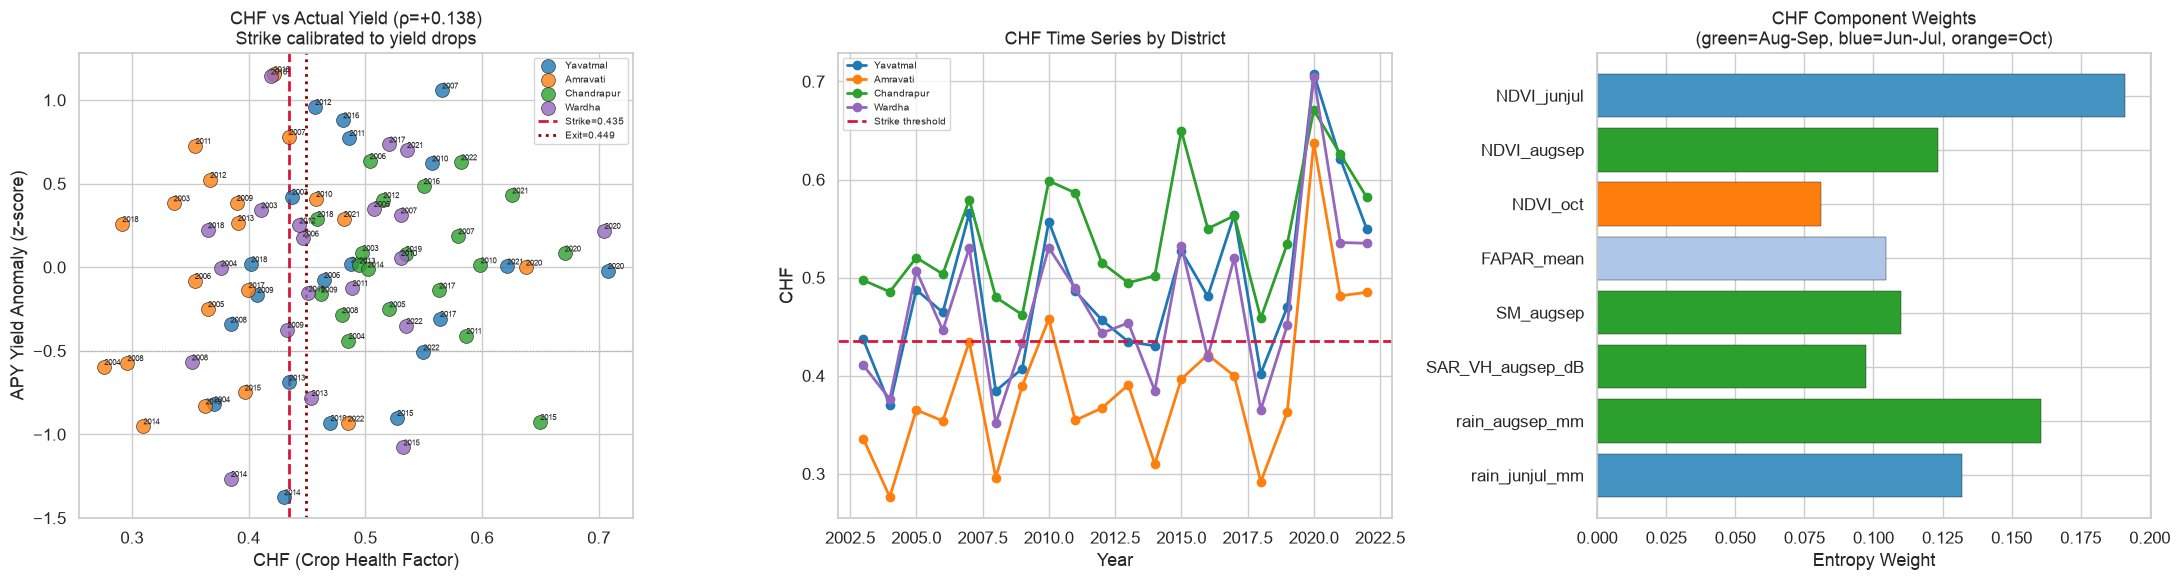

Saved → vidarbha_outputs/chf_calibration_v8.png

=== KNOWN DROUGHT YEARS IN CALIBRATION ===
  2003: CHF=0.420  APY_z=+0.31
  2004: CHF=0.377  APY_z=-0.46
  2005: CHF=0.470  APY_z=-0.03
  2006: CHF=0.442  APY_z=+0.16
  2007: CHF=0.528  APY_z=+0.58  ← GOOD
  2008: CHF=0.378  APY_z=-0.44
  2009: CHF=0.423  APY_z=-0.08
  2010: CHF=0.536  APY_z=+0.28
  2011: CHF=0.479  APY_z=+0.24
  2012: CHF=0.446  APY_z=+0.53  ← GOOD
  2013: CHF=0.443  APY_z=-0.30
  2014: CHF=0.407  APY_z=-0.90  ← DROUGHT
  2015: CHF=0.527  APY_z=-0.91  ← DROUGHT
  2016: CHF=0.468  APY_z=+0.92  ← GOOD
  2017: CHF=0.512  APY_z=+0.04
  2018: CHF=0.379  APY_z=+0.20
  2019: CHF=0.455  APY_z=-0.46
  2020: CHF=0.680  APY_z=+0.07
  2021: CHF=0.566  APY_z=+0.36
  2022: CHF=0.538  APY_z=-0.29


In [4]:
# ── CHF vs APY yield — district-year level calibration ────────────────────────
dist_yr_chf = bt.groupby(['district','year'])['CHF'].mean().reset_index()
apy_merge_cols = ['year','district','crop_stress_z','crop_stress_z_2crop']
apy_merge_cols += [c for c in apy_raw.columns if c.endswith('_z')]
apy_merge_cols = [c for c in apy_merge_cols if c in apy_raw.columns]
dist_yr_chf = dist_yr_chf.merge(
    apy_raw[list(set(apy_merge_cols))],
    on=['district','year'], how='inner'
)

# Also merge PMFBY for comparison
pmfby_dy = bt[bt['rate_total'].notna()].groupby(['district','year'])['rate_total'].mean().reset_index()
dist_yr_chf = dist_yr_chf.merge(pmfby_dy, on=['district','year'], how='left')

print('=== CHF CORRELATION WITH GROUND TRUTH ===')
print(f'District-year observations: {len(dist_yr_chf)}')
print()

# CHF vs APY crop stress
rho_apy, p_apy = spearmanr(dist_yr_chf['CHF'], dist_yr_chf['crop_stress_z'])
print(f'CHF vs APY crop_stress_z:  ρ={rho_apy:+.3f}  p={p_apy:.4f}')

# CHF vs PMFBY
valid_pm = dist_yr_chf.dropna(subset=['rate_total'])
rho_pm, p_pm = spearmanr(valid_pm['CHF'], valid_pm['rate_total'])
print(f'CHF vs PMFBY rate_total:   ρ={rho_pm:+.3f}  p={p_pm:.4f}')

# For reference: best single-feature correlation from v6
print()
print('For comparison:')
print(f'  v7 (8yr):  ρ≈-0.10  (28 calibration points)')
print(f'  v8 (23yr): ρ={rho_apy:+.3f}  ({len(dist_yr_chf)} calibration points)')

# ── Yield-calibrated threshold ────────────────────────────────────────────────
# Find CHF value that best separates "bad yield years" (crop_stress_z < -0.5)
# from normal/good years. Use ROC-like approach.

bad_mask = dist_yr_chf['crop_stress_z'] < -0.5
n_bad = bad_mask.sum()
print(f'\nBad yield district-years (z < -0.5): {n_bad}/{len(dist_yr_chf)}')

# Sweep CHF thresholds and compute F1
best_f1, best_thr = 0, 0
results = []
for thr in np.arange(0.30, 0.60, 0.005):
    pred_bad = dist_yr_chf['CHF'] < thr
    tp = (pred_bad & bad_mask).sum()
    fp = (pred_bad & ~bad_mask).sum()
    fn = (~pred_bad & bad_mask).sum()
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
    results.append((thr, prec, rec, f1, tp, fp, fn))
    if f1 > best_f1:
        best_f1, best_thr = f1, thr

CHF_STRIKE = best_thr
print(f'\nOptimal CHF threshold (max F1 on APY bad years):')
print(f'  Strike = {CHF_STRIKE:.3f}  (CHF below this → trigger)')
print(f'  F1 = {best_f1:.2f}')

# Also set exit for tiered payout
# Exit = where yields are catastrophically bad (z < -1.0)
catastrophic = dist_yr_chf['crop_stress_z'] < -1.0
if catastrophic.sum() > 0:
    CHF_EXIT = dist_yr_chf.loc[catastrophic, 'CHF'].mean()
else:
    CHF_EXIT = CHF_STRIKE - 0.05
print(f'  Exit  = {CHF_EXIT:.3f}  (max payout below this)')

# ── Flood threshold: sub-window rainfall ──────────────────────────────────────
# Aug-Sep excess rainfall: use per-district IMD standard
print()
print('FLOOD: Rain_augsep > 60% of kharif LPA (per-district IMD excess)')
for dist, lpa in DISTRICT_LPA.items():
    flood_thr = lpa * 0.60  # Aug-Sep is ~60% of kharif
    excess_thr = flood_thr * 1.20
    print(f'  {dist:12s}: augsep_normal={flood_thr:.0f}mm  excess>{excess_thr:.0f}mm')

# ── Visualization ─────────────────────────────────────────────────────────────
DIST_COLORS = {'Yavatmal': '#1f77b4', 'Amravati': '#ff7f0e',
               'Chandrapur': '#2ca02c', 'Wardha': '#9467bd'}

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# Panel 1: CHF vs APY yield anomaly
ax = axes[0]
for dist, color in DIST_COLORS.items():
    sub = dist_yr_chf[dist_yr_chf['district']==dist]
    ax.scatter(sub['CHF'], sub['crop_stress_z'], c=color, s=100, alpha=0.8,
               edgecolors='k', lw=0.5, label=dist, zorder=3)
    for _, row in sub.iterrows():
        ax.annotate(str(int(row['year'])), (row['CHF'], row['crop_stress_z']),
                    fontsize=6, ha='left', va='bottom')
ax.axvline(CHF_STRIKE, color='crimson', ls='--', lw=2, label=f'Strike={CHF_STRIKE:.3f}')
ax.axvline(CHF_EXIT, color='darkred', ls=':', lw=2, label=f'Exit={CHF_EXIT:.3f}')
ax.axhline(-0.5, color='grey', ls=':', lw=0.8, alpha=0.5)
ax.set_xlabel('CHF (Crop Health Factor)')
ax.set_ylabel('APY Yield Anomaly (z-score)')
ax.set_title(f'CHF vs Actual Yield (ρ={rho_apy:+.3f})\nStrike calibrated to yield drops')
ax.legend(fontsize=7)

# Panel 2: CHF time series by district
ax = axes[1]
for dist, color in DIST_COLORS.items():
    sub = dist_yr_chf[dist_yr_chf['district']==dist].sort_values('year')
    ax.plot(sub['year'], sub['CHF'], '-o', color=color, label=dist, lw=2, markersize=6)
ax.axhline(CHF_STRIKE, color='crimson', ls='--', lw=2, label='Strike threshold')
ax.set_xlabel('Year')
ax.set_ylabel('CHF')
ax.set_title('CHF Time Series by District')
ax.legend(fontsize=7)

# Panel 3: Entropy weights bar chart
ax = axes[2]
labels = [c.replace('_norm','') for c in entropy_weights.keys()]
weights = list(entropy_weights.values())
colors = ['#2ca02c' if 'augsep' in l else '#4393c3' if 'junjul' in l
          else '#ff7f0e' if 'oct' in l else '#aec7e8' for l in labels]
ax.barh(labels, weights, color=colors, edgecolor='k', lw=0.3)
ax.set_xlabel('Entropy Weight')
ax.set_title('CHF Component Weights\n(green=Aug-Sep, blue=Jun-Jul, orange=Oct)')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig(OUT / 'chf_calibration_v8.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → vidarbha_outputs/chf_calibration_v8.png')

# Show known drought years in calibration data
print()
print('=== KNOWN DROUGHT YEARS IN CALIBRATION ===')
for yr in sorted(dist_yr_chf['year'].unique()):
    sub = dist_yr_chf[dist_yr_chf['year']==yr]
    z = sub['crop_stress_z'].mean()
    chf = sub['CHF'].mean()
    tag = '  ← DROUGHT' if z < -0.5 else ('  ← GOOD' if z > 0.5 else '')
    print(f'  {yr}: CHF={chf:.3f}  APY_z={z:+.2f}{tag}')

## B2 · PMFBY-Calibrated Threshold — CHF vs PMFBY rate_yield

Since APY district-level yields are noisy, let's also calibrate CHF directly against PMFBY's drought payout ratio (`rate_yield`). PMFBY has RC-level granularity (not just district) and reflects actual assessed losses. We use this as an **alternative ground truth** — not to copy PMFBY, but because it's a better signal of what actually happened on the ground.

In [5]:
# ── CHF vs PMFBY — RC-level calibration (2018-2024) ──────────────────────────
bt_pm = bt[(bt['year'].isin(PMFBY_YEARS)) & (bt['rate_total'].notna())].copy()

print('=== CHF vs PMFBY CORRELATION (RC-level) ===')
print(f'RC-year observations with PMFBY data: {len(bt_pm)}')

# RC-level correlations
for target, label in [('rate_total', 'rate_total (all claims)'),
                       ('rate_yield', 'rate_yield (drought claims)')]:
    valid = bt_pm[bt_pm[target].notna() & bt_pm['CHF'].notna()]
    if len(valid) > 10:
        rho, p = spearmanr(valid['CHF'], valid[target])
        print(f'  CHF vs {label:35s}: ρ={rho:+.3f}  p={p:.4f}  n={len(valid)}')

# District-year level
print()
print('=== CHF vs PMFBY CORRELATION (district-year level) ===')
dy_pm = bt_pm.groupby(['district','year']).agg(
    CHF=('CHF','mean'),
    rate_total=('rate_total','mean'),
    rate_yield=('rate_yield','mean'),
).reset_index()

for target, label in [('rate_total', 'rate_total'), ('rate_yield', 'rate_yield')]:
    valid = dy_pm[dy_pm[target].notna()]
    if len(valid) > 5:
        rho, p = spearmanr(valid['CHF'], valid[target])
        print(f'  CHF vs {label:20s}: ρ={rho:+.3f}  p={p:.4f}  n={len(valid)}')

# ── PMFBY-calibrated threshold ────────────────────────────────────────────────
# Use rate_yield > 10% as "PMFBY drought event"
pmfby_bad = bt_pm['rate_yield'] > PMFBY_LOSS_THRESHOLD
n_bad_pm = pmfby_bad.sum()
print(f'\nPMFBY drought events (rate_yield > {PMFBY_LOSS_THRESHOLD:.0%}): {n_bad_pm}/{len(bt_pm)}')

best_f1_pm, best_thr_pm = 0, 0
for thr in np.arange(0.25, 0.65, 0.005):
    pred_bad = bt_pm['CHF'] < thr
    tp = (pred_bad & pmfby_bad).sum()
    fp = (pred_bad & ~pmfby_bad).sum()
    fn = (~pred_bad & pmfby_bad).sum()
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
    if f1 > best_f1_pm:
        best_f1_pm, best_thr_pm = f1, thr

CHF_STRIKE_PM = best_thr_pm
CHF_EXIT_PM   = CHF_STRIKE_PM - 0.08

print(f'\nPMFBY-calibrated CHF threshold:')
print(f'  Strike = {CHF_STRIKE_PM:.3f}  (F1 = {best_f1_pm:.2f})')
print(f'  Exit   = {CHF_EXIT_PM:.3f}')
print()
print(f'Compare with APY-calibrated:')
print(f'  APY  Strike = {CHF_STRIKE:.3f}')
print(f'  PMFBY Strike = {CHF_STRIKE_PM:.3f}')

# ── Individual feature correlations with PMFBY ────────────────────────────────
print()
print('=== INDIVIDUAL FEATURE CORRELATIONS WITH PMFBY rate_yield ===')
feat_cols = ['NDVI_mean', 'NDVI_anom', 'VHI_mean', 'LST_mean_C', 'LST_anom_C',
             'cumRain_mm', 'FAPAR_mean', 'FAPAR_anom', 'SMAP_sm_mean', 'SMAP_sm_anom',
             'SAR_VH_mean_dB', 'SAR_CR_mean_dB', 'SM_mean', 'SM_anom',
             'NDVI_junjul', 'NDVI_augsep', 'NDVI_oct',
             'rain_junjul_mm', 'rain_augsep_mm', 'rain_oct_mm',
             'drySpellDays', 'heavy_rain_days', 'lst_anom_augsep',
             'gdd_surplus', 'sm_wet_days', 'CHF']

results_corr = []
for feat in feat_cols:
    if feat in bt_pm.columns:
        valid = bt_pm[[feat, 'rate_yield']].dropna()
        if len(valid) > 20:
            rho, p = spearmanr(valid[feat], valid['rate_yield'])
            results_corr.append((feat, rho, p, len(valid)))

results_corr.sort(key=lambda x: abs(x[1]), reverse=True)
print(f'{"Feature":25s} {"ρ":>8s} {"p-val":>8s} {"n":>6s}')
for feat, rho, p, n in results_corr:
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))
    print(f'  {feat:23s} {rho:+.3f}   {p:.4f}  {n:>5d} {sig}')

=== CHF vs PMFBY CORRELATION (RC-level) ===
RC-year observations with PMFBY data: 1119
  CHF vs rate_total (all claims)            : ρ=-0.116  p=0.0001  n=1119
  CHF vs rate_yield (drought claims)        : ρ=-0.061  p=0.0417  n=1119

=== CHF vs PMFBY CORRELATION (district-year level) ===
  CHF vs rate_total          : ρ=+0.252  p=0.2252  n=25
  CHF vs rate_yield          : ρ=+0.126  p=0.5479  n=25

PMFBY drought events (rate_yield > 10%): 209/1119

PMFBY-calibrated CHF threshold:
  Strike = 0.485  (F1 = 0.35)
  Exit   = 0.405

Compare with APY-calibrated:
  APY  Strike = 0.435
  PMFBY Strike = 0.485

=== INDIVIDUAL FEATURE CORRELATIONS WITH PMFBY rate_yield ===
Feature                          ρ    p-val      n
  LST_anom_C              +0.478   0.0000   1119 ***
  LST_mean_C              +0.440   0.0000   1119 ***
  rain_augsep_mm          +0.374   0.0000   1119 ***
  FAPAR_mean              -0.291   0.0000   1119 ***
  gdd_surplus             +0.266   0.0000   1119 ***
  SAR_CR_mean_

=== APY vs PMFBY CALIBRATION COMPARISON (on PMFBY years 2018-2024) ===

APY-calibrated (Strike=0.435):
  Fire rate:  30%
  Aligned:    153/1119 (13.7%)
  Value-add:  187/1119 (16.7%)
  Basis risk: 285/1119 (25.5%)
  Quiet:      494/1119 (44.1%)
  PMFBY recall: 153/438 (35%)

PMFBY-calibrated (Strike=0.485):
  Fire rate:  44%
  Aligned:    217/1119 (19.4%)
  Value-add:  277/1119 (24.8%)
  Basis risk: 221/1119 (19.7%)
  Quiet:      404/1119 (36.1%)
  PMFBY recall: 217/438 (50%)

=== SUMMARY ===
                             APY-calib  PMFBY-calib
--------------------------------------------------
Strike                           0.435        0.485
Fire rate                         30%         44%
PMFBY recall                      35%         50%
Basis risk                      25.5%       19.7%
Value-add                       16.7%       24.8%


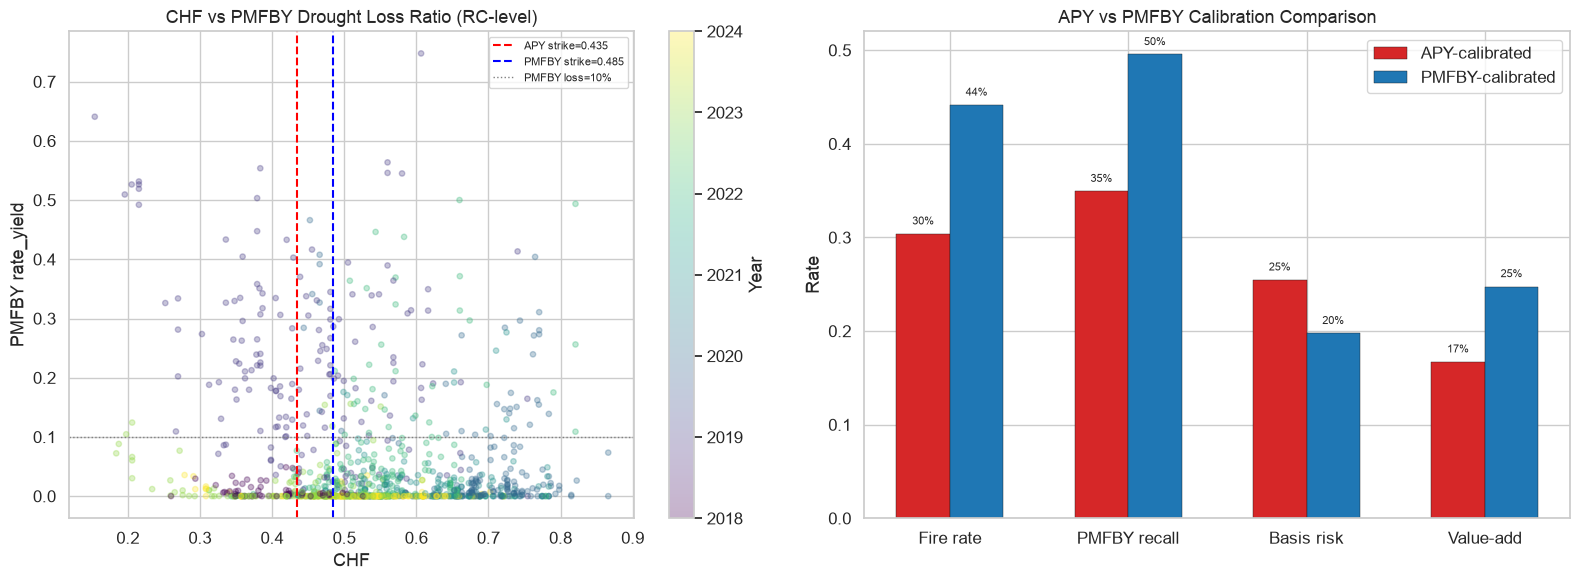

Saved → vidarbha_outputs/chf_apy_vs_pmfby_calibration_v8.png


In [6]:
# ── Compare APY-calibrated vs PMFBY-calibrated triggers ──────────────────────
# Re-run triggers with PMFBY-calibrated threshold
bt_compare = bt[bt['year'].isin(PMFBY_YEARS) & bt['rate_total'].notna()].copy()

def evaluate_threshold(data, strike, exit_val, label):
    d = data.copy()
    d['trig'] = d['CHF'] < strike
    
    # Flood trigger stays the same
    def flood_check(row):
        lpa = DISTRICT_LPA.get(row.get('district', 'Yavatmal'), 950)
        augsep_lpa = lpa * 0.58
        return row['rain_augsep_mm'] > augsep_lpa * 1.20
    d['trig_flood'] = d.apply(flood_check, axis=1)
    d['trig_any'] = d['trig'] | d['trig_flood']
    
    pmfby_stress = d['rate_total'] > PMFBY_LOSS_THRESHOLD
    aligned = (d['trig_any'] & pmfby_stress).sum()
    value_add = (d['trig_any'] & ~pmfby_stress).sum()
    basis_risk = (~d['trig_any'] & pmfby_stress).sum()
    quiet = (~d['trig_any'] & ~pmfby_stress).sum()
    total = len(d)
    pmfby_events = pmfby_stress.sum()
    
    recall = aligned / pmfby_events if pmfby_events > 0 else 0
    fire_rate = d['trig_any'].mean()
    
    print(f'\n{label} (Strike={strike:.3f}):')
    print(f'  Fire rate:  {fire_rate:.0%}')
    print(f'  Aligned:    {aligned}/{total} ({aligned/total:.1%})')
    print(f'  Value-add:  {value_add}/{total} ({value_add/total:.1%})')
    print(f'  Basis risk: {basis_risk}/{total} ({basis_risk/total:.1%})')
    print(f'  Quiet:      {quiet}/{total} ({quiet/total:.1%})')
    print(f'  PMFBY recall: {aligned}/{pmfby_events} ({recall:.0%})')
    return {'label': label, 'strike': strike, 'fire_rate': fire_rate,
            'recall': recall, 'basis_risk': basis_risk/total,
            'value_add': value_add/total, 'aligned': aligned/total}

print('=== APY vs PMFBY CALIBRATION COMPARISON (on PMFBY years 2018-2024) ===')
r_apy = evaluate_threshold(bt_compare, CHF_STRIKE, CHF_EXIT, 'APY-calibrated')
r_pm  = evaluate_threshold(bt_compare, CHF_STRIKE_PM, CHF_EXIT_PM, 'PMFBY-calibrated')

# Summary table
print()
print('=== SUMMARY ===')
print(f'{"":25s} {"APY-calib":>12s} {"PMFBY-calib":>12s}')
print('-' * 50)
print(f'{"Strike":25s} {CHF_STRIKE:>12.3f} {CHF_STRIKE_PM:>12.3f}')
print(f'{"Fire rate":25s} {r_apy["fire_rate"]:>11.0%} {r_pm["fire_rate"]:>11.0%}')
print(f'{"PMFBY recall":25s} {r_apy["recall"]:>11.0%} {r_pm["recall"]:>11.0%}')
print(f'{"Basis risk":25s} {r_apy["basis_risk"]:>11.1%} {r_pm["basis_risk"]:>11.1%}')
print(f'{"Value-add":25s} {r_apy["value_add"]:>11.1%} {r_pm["value_add"]:>11.1%}')

# ── Visualization ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter: CHF vs PMFBY rate_yield
ax = axes[0]
valid_pm = bt_compare[bt_compare['rate_yield'].notna()]
sc = ax.scatter(valid_pm['CHF'], valid_pm['rate_yield'],
                alpha=0.3, s=15, c=valid_pm['year'], cmap='viridis')
ax.axvline(CHF_STRIKE, color='red', ls='--', lw=1.5, label=f'APY strike={CHF_STRIKE:.3f}')
ax.axvline(CHF_STRIKE_PM, color='blue', ls='--', lw=1.5, label=f'PMFBY strike={CHF_STRIKE_PM:.3f}')
ax.axhline(PMFBY_LOSS_THRESHOLD, color='gray', ls=':', lw=1, label=f'PMFBY loss={PMFBY_LOSS_THRESHOLD:.0%}')
ax.set_xlabel('CHF')
ax.set_ylabel('PMFBY rate_yield')
ax.set_title('CHF vs PMFBY Drought Loss Ratio (RC-level)')
ax.legend(fontsize=8)
plt.colorbar(sc, ax=ax, label='Year')

# Bar chart comparison
ax = axes[1]
metrics = ['Fire rate', 'PMFBY recall', 'Basis risk', 'Value-add']
apy_vals = [r_apy['fire_rate'], r_apy['recall'], r_apy['basis_risk'], r_apy['value_add']]
pm_vals  = [r_pm['fire_rate'], r_pm['recall'], r_pm['basis_risk'], r_pm['value_add']]
x = np.arange(len(metrics))
ax.bar(x - 0.15, apy_vals, 0.3, label='APY-calibrated', color='#d62728', edgecolor='k', lw=0.3)
ax.bar(x + 0.15, pm_vals, 0.3, label='PMFBY-calibrated', color='#1f77b4', edgecolor='k', lw=0.3)
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel('Rate')
ax.set_title('APY vs PMFBY Calibration Comparison')
ax.legend()
for i, (a, p) in enumerate(zip(apy_vals, pm_vals)):
    ax.text(i - 0.15, a + 0.01, f'{a:.0%}', ha='center', fontsize=8)
    ax.text(i + 0.15, p + 0.01, f'{p:.0%}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig(OUT / 'chf_apy_vs_pmfby_calibration_v8.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → vidarbha_outputs/chf_apy_vs_pmfby_calibration_v8.png')

## C · CHF Trigger + Tiered Payout

In [7]:
# ── CHF-based triggers ────────────────────────────────────────────────────────
# Drought: CHF < strike (composite crop health below calibrated threshold)
# Flood: Aug-Sep rainfall > per-district excess (IMD 120% of sub-season LPA)

def apply_triggers_v7(d, chf_strike, chf_exit, district_lpa):
    d = d.copy()

    # Drought trigger: CHF below yield-calibrated strike
    d['trigger_drought'] = d['CHF'] < chf_strike

    # Flood trigger: Aug-Sep rain > 120% of sub-season LPA
    # Aug-Sep is roughly 55-60% of total kharif rainfall
    def flood_check(row):
        lpa = district_lpa.get(row.get('district', 'Yavatmal'), 950)
        augsep_lpa = lpa * 0.58  # Aug-Sep share of kharif
        return row['rain_augsep_mm'] > augsep_lpa * 1.20
    d['trigger_flood'] = d.apply(flood_check, axis=1)

    d['trigger_any'] = d['trigger_drought'] | d['trigger_flood']

    # Drought payout: linear between strike and exit
    def drought_payout(row):
        if not row['trigger_drought']:
            return 0.0
        chf = row['CHF']
        if chf >= chf_strike:
            return 0.0
        elif chf <= chf_exit:
            return 0.25  # cap at 25%
        else:
            return 0.05 + (chf_strike - chf) / (chf_strike - chf_exit) * 0.20

    # Flood payout: linear based on excess rainfall
    def flood_payout(row):
        if not row['trigger_flood']:
            return 0.0
        lpa = district_lpa.get(row.get('district', 'Yavatmal'), 950)
        augsep_lpa = lpa * 0.58
        pct = row['rain_augsep_mm'] / augsep_lpa
        if pct <= 1.20:
            return 0.0
        elif pct <= 1.50:
            return 0.05 + (pct - 1.20) / 0.30 * 0.10
        elif pct <= 1.80:
            return 0.15 + (pct - 1.50) / 0.30 * 0.10
        else:
            return 0.25

    d['payout_drought_pct'] = d.apply(drought_payout, axis=1)
    d['payout_flood_pct']   = d.apply(flood_payout, axis=1)
    d['payout_total_pct']   = d[['payout_drought_pct','payout_flood_pct']].max(axis=1)
    d['payout_rs_per_ha']   = d['payout_total_pct'] * SUM_INSURED_PER_HA

    return d


bt = apply_triggers_v7(bt, CHF_STRIKE, CHF_EXIT, DISTRICT_LPA)
nc = apply_triggers_v7(nc, CHF_STRIKE, CHF_EXIT, DISTRICT_LPA)

print('=== TRIGGER ACTIVATION RATES (v8: CHF + flood, 23yr backtest) ===')
print(f'Overall fire rate (2003-2024): {bt["trigger_any"].mean():.0%}')
print(f'  Drought: {bt["trigger_drought"].mean():.0%}  |  Flood: {bt["trigger_flood"].mean():.0%}')
print()

# Show PMFBY-comparable years
bt_pm = bt[bt['year'].isin(PMFBY_YEARS)]
has_pmfby = bt_pm['rate_total'].notna()
print(f'PMFBY-comparable years ({PMFBY_YEARS[0]}-{PMFBY_YEARS[-1]}):')
print(f'  Our fire rate: {bt_pm["trigger_any"].mean():.0%}')
if has_pmfby.sum() > 0:
    print(f'  PMFBY stress rate (>10%): {bt_pm.loc[has_pmfby, "pmfby_stress"].mean():.0%}')

# ── Payout results ────────────────────────────────────────────────────────────
print()
print('=== PAYOUT RESULTS ===')
print(f'Sum insured: ₹{SUM_INSURED_PER_HA:,}/ha')
for yr in BACKTEST_YEARS:
    s = bt[bt['year']==yr]
    triggered = s['trigger_any'].sum()
    avg_payout = s['payout_total_pct'].mean()
    avg_triggered = s.loc[s['trigger_any'], 'payout_total_pct'].mean() if triggered > 0 else 0
    avg_rs = s['payout_rs_per_ha'].mean()
    print(f'  {yr}: {triggered:3d}/{len(s)} triggered | '
          f'avg (all): {avg_payout:.1%} | avg (triggered): {avg_triggered:.1%} | '
          f'₹/ha: {avg_rs:,.0f}')

=== TRIGGER ACTIVATION RATES (v8: CHF + flood, 23yr backtest) ===
Overall fire rate (2003-2024): 46%
  Drought: 38%  |  Flood: 9%

PMFBY-comparable years (2018-2024):
  Our fire rate: 39%
  PMFBY stress rate (>10%): 39%

=== PAYOUT RESULTS ===
Sum insured: ₹40,000/ha
  2003: 155/277 triggered | avg (all): 14.0% | avg (triggered): 25.0% | ₹/ha: 5,596
  2004: 199/277 triggered | avg (all): 18.0% | avg (triggered): 25.0% | ₹/ha: 7,184
  2005:  88/277 triggered | avg (all): 7.9% | avg (triggered): 25.0% | ₹/ha: 3,177
  2006: 176/277 triggered | avg (all): 13.0% | avg (triggered): 20.5% | ₹/ha: 5,214
  2007:  42/277 triggered | avg (all): 3.5% | avg (triggered): 22.9% | ₹/ha: 1,391
  2008: 210/277 triggered | avg (all): 19.0% | avg (triggered): 25.0% | ₹/ha: 7,581
  2009: 158/277 triggered | avg (all): 14.3% | avg (triggered): 25.0% | ₹/ha: 5,704
  2010: 224/277 triggered | avg (all): 11.8% | avg (triggered): 14.6% | ₹/ha: 4,732
  2011: 111/277 triggered | avg (all): 9.1% | avg (triggered):

## D · Backtest vs PMFBY — Coverage Analysis (v7)

=== BACKTEST COVERAGE ANALYSIS (v8 — CHF, 23yr calibration) ===
Total RC×year obs (with PMFBY data, 2018-2024): 1119

  Aligned (both)           :  153 / 1119 (13.7%)
  Our value-add            :  187 / 1119 (16.7%)
  Our basis risk           :  285 / 1119 (25.5%)
  Quiet (neither)          :  494 / 1119 (44.1%)

Recall on PMFBY events: 153/438 (35%)
Our value-add: 187 RC-years we pay but PMFBY didn't
Our basis risk: 285 RC-years PMFBY paid but we didn't

  Year    PMFBY     Ours  Aligned    V-add   B-risk
  2018        0       43        0       43        0
  2019      129      146      108       38       21
  2020       40       14        4       10       36
  2021       61        8        0        8       61
  2022      136       44       29       15      107
  2023       67       65       11       54       56
  2024        5       20        1       19        4

=== FULL 22-YEAR TRIGGER RATES ===
  Year  Drought    Flood      Any   CHF_mean    APY_z
  2003      56%       0%      56% 

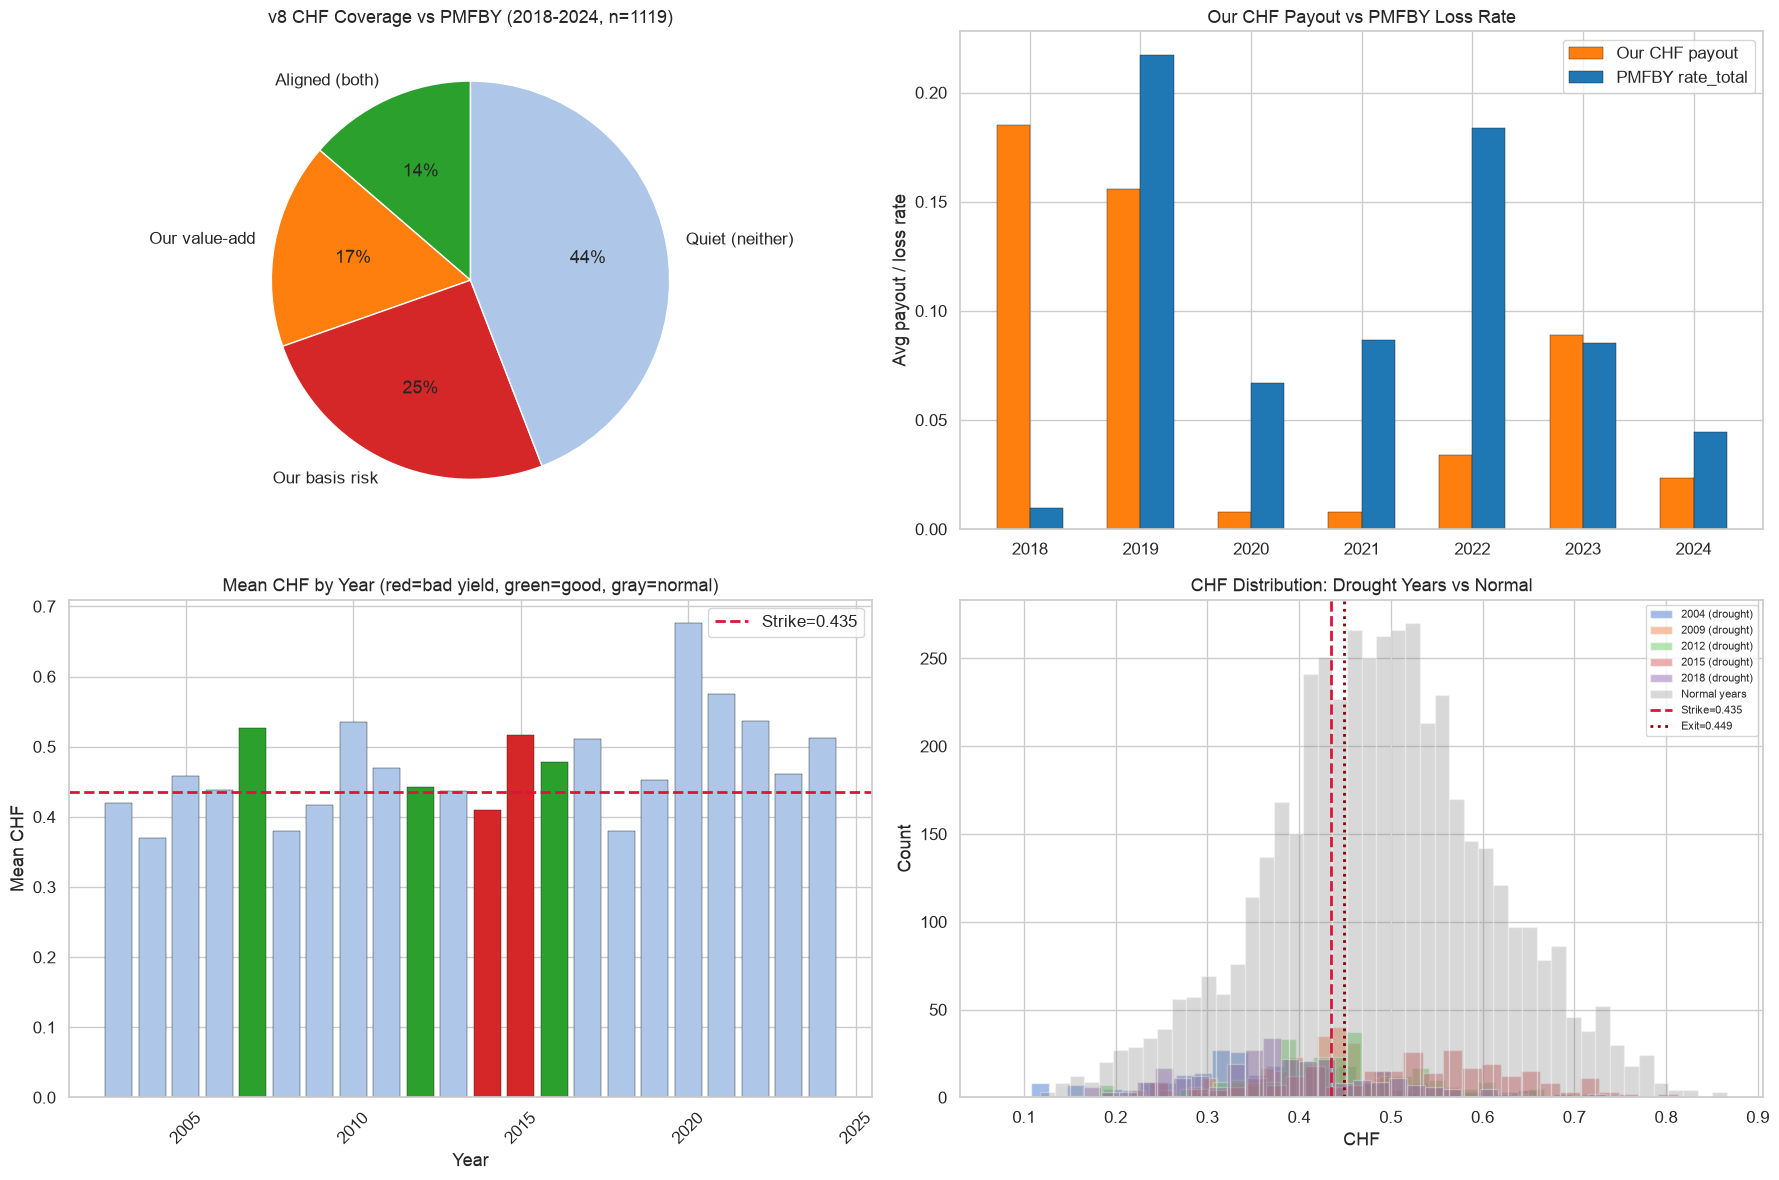

Saved → vidarbha_outputs/chf_backtest_v8.png


In [8]:
# ── Coverage analysis vs PMFBY (2018-2024 only) ──────────────────────────────
bt_pmfby = bt[(bt['year'].isin(PMFBY_YEARS)) & (bt['rate_total'].notna())].copy()

def categorise(row):
    we   = row['trigger_any']
    them = row['pmfby_stress']
    if     we and     them: return 'Aligned (both)',    '#2ca02c'
    if     we and not them: return 'Our value-add',     '#ff7f0e'
    if not we and     them: return 'Our basis risk',    '#d62728'
    return                         'Quiet (neither)',   '#aec7e8'

cats = bt_pmfby.apply(categorise, axis=1)
bt_pmfby['category'] = [c[0] for c in cats]
cat_counts = bt_pmfby['category'].value_counts()
total = len(bt_pmfby)

print('=== BACKTEST COVERAGE ANALYSIS (v8 — CHF, 23yr calibration) ===')
print(f'Total RC×year obs (with PMFBY data, {PMFBY_YEARS[0]}-{PMFBY_YEARS[-1]}): {total}')
print()
for cat in ['Aligned (both)', 'Our value-add', 'Our basis risk', 'Quiet (neither)']:
    n = cat_counts.get(cat, 0)
    print(f'  {cat:25s}: {n:4d} / {total} ({n/total:.1%})')

pmfby_events = bt_pmfby['pmfby_stress'].sum()
aligned = cat_counts.get('Aligned (both)', 0)
basis_risk = cat_counts.get('Our basis risk', 0)
value_add = cat_counts.get('Our value-add', 0)
our_triggers = aligned + value_add

print(f'\nRecall on PMFBY events: {aligned}/{int(pmfby_events)} ({aligned/pmfby_events:.0%})')
print(f'Our value-add: {value_add} RC-years we pay but PMFBY didn\'t')
print(f'Our basis risk: {basis_risk} RC-years PMFBY paid but we didn\'t')

# ── Year-by-year breakdown (PMFBY years) ──────────────────────────────────────
print()
print(f'{"Year":>6s} {"PMFBY":>8s} {"Ours":>8s} {"Aligned":>8s} {"V-add":>8s} {"B-risk":>8s}')
for yr in PMFBY_YEARS:
    s = bt_pmfby[bt_pmfby['year']==yr]
    if len(s) == 0:
        continue
    pe = int(s['pmfby_stress'].sum())
    ot = int(s['trigger_any'].sum())
    al = int((s['category']=='Aligned (both)').sum())
    va = int((s['category']=='Our value-add').sum())
    br = int((s['category']=='Our basis risk').sum())
    print(f'{yr:>6d} {pe:>8d} {ot:>8d} {al:>8d} {va:>8d} {br:>8d}')

# ── Full backtest trigger rates (all 22 years) ───────────────────────────────
print()
print('=== FULL 22-YEAR TRIGGER RATES ===')
print(f'{"Year":>6s} {"Drought":>8s} {"Flood":>8s} {"Any":>8s} {"CHF_mean":>10s} {"APY_z":>8s}')
for yr in BACKTEST_YEARS:
    s = bt[bt['year']==yr]
    dr = s['trigger_drought'].mean()
    fl = s['trigger_flood'].mean()
    an = s['trigger_any'].mean()
    chf = s['CHF'].mean()
    apy_yr = apy_raw[apy_raw['year']==yr]['crop_stress_z'].mean()
    apy_str = f'{apy_yr:+.2f}' if not np.isnan(apy_yr) else '  N/A'
    tag = ' ←BAD' if (not np.isnan(apy_yr) and apy_yr < -0.5) else ''
    print(f'{yr:>6d} {dr:>8.0%} {fl:>8.0%} {an:>8.0%} {chf:>10.3f} {apy_str:>8s}{tag}')

# ── Visualization ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Panel 1: coverage pie (PMFBY years)
ax = axes[0, 0]
cat_order = ['Aligned (both)', 'Our value-add', 'Our basis risk', 'Quiet (neither)']
cat_colors_map = {'Aligned (both)': '#2ca02c', 'Our value-add': '#ff7f0e',
                  'Our basis risk': '#d62728', 'Quiet (neither)': '#aec7e8'}
sizes = [cat_counts.get(c, 0) for c in cat_order]
ax.pie(sizes, labels=cat_order, colors=[cat_colors_map[c] for c in cat_order],
       autopct='%1.0f%%', startangle=90)
ax.set_title(f'v8 CHF Coverage vs PMFBY ({PMFBY_YEARS[0]}-{PMFBY_YEARS[-1]}, n={total})')

# Panel 2: our payout vs PMFBY by year (PMFBY years only)
ax = axes[0, 1]
yr_ours  = bt_pmfby.groupby('year')['payout_total_pct'].mean()
yr_pmfby = bt_pmfby.groupby('year')['rate_total'].mean()
x = np.arange(len(PMFBY_YEARS))
ax.bar(x - 0.15, [yr_ours.get(y, 0) for y in PMFBY_YEARS], 0.3,
       label='Our CHF payout', color='#ff7f0e', edgecolor='k', lw=0.3)
ax.bar(x + 0.15, [yr_pmfby.get(y, 0) for y in PMFBY_YEARS], 0.3,
       label='PMFBY rate_total', color='#1f77b4', edgecolor='k', lw=0.3)
ax.set_xticks(x)
ax.set_xticklabels([str(y) for y in PMFBY_YEARS])
ax.set_ylabel('Avg payout / loss rate')
ax.set_title('Our CHF Payout vs PMFBY Loss Rate')
ax.legend()

# Panel 3: CHF by year (full 22 years) with APY overlay
ax = axes[1, 0]
yr_chf_all = bt.groupby('year')['CHF'].mean()
apy_by_yr = apy_raw.groupby('year')['crop_stress_z'].mean()
years_plot = BACKTEST_YEARS
ax.bar(years_plot, [yr_chf_all.get(y, 0) for y in years_plot],
       color=['#d62728' if apy_by_yr.get(y, 0) < -0.5 else '#2ca02c' if apy_by_yr.get(y, 0) > 0.5 else '#aec7e8'
              for y in years_plot],
       edgecolor='k', lw=0.3)
ax.axhline(CHF_STRIKE, color='crimson', lw=2, ls='--', label=f'Strike={CHF_STRIKE:.3f}')
ax.set_xlabel('Year')
ax.set_ylabel('Mean CHF')
ax.set_title('Mean CHF by Year (red=bad yield, green=good, gray=normal)')
ax.legend()
ax.tick_params(axis='x', rotation=45)

# Panel 4: CHF distribution with threshold
ax = axes[1, 1]
known_droughts = [2004, 2009, 2012, 2015, 2018]
for yr in known_droughts:
    if yr in BACKTEST_YEARS:
        yr_chf_vals = bt[bt['year']==yr]['CHF']
        ax.hist(yr_chf_vals, bins=30, alpha=0.5, label=f'{yr} (drought)')
normal_chf = bt[~bt['year'].isin(known_droughts)]['CHF']
ax.hist(normal_chf, bins=50, alpha=0.3, label='Normal years', color='gray')
ax.axvline(CHF_STRIKE, color='crimson', lw=2, ls='--', label=f'Strike={CHF_STRIKE:.3f}')
ax.axvline(CHF_EXIT, color='darkred', lw=2, ls=':', label=f'Exit={CHF_EXIT:.3f}')
ax.set_xlabel('CHF')
ax.set_ylabel('Count')
ax.set_title('CHF Distribution: Drought Years vs Normal')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUT / 'chf_backtest_v8.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → vidarbha_outputs/chf_backtest_v8.png')

## E · 2025 Nowcast

In [9]:
# ── 2025 Nowcast ──────────────────────────────────────────────────────────────
print('=== 2025 NOWCAST (v8 — CHF, 23yr calibration) ===')
print(f'CHF Strike: {CHF_STRIKE:.3f}  |  Exit: {CHF_EXIT:.3f}')
print()

for col, label in [
    ('trigger_drought', f'Drought (CHF < {CHF_STRIKE:.3f})'),
    ('trigger_flood',   'Flood (rain_augsep excess)'),
    ('trigger_any',     'ANY → payout'),
]:
    n = nc[col].sum()
    pct = nc[col].mean()
    print(f'  {label:35s}: {n:3d} / {len(nc)} RCs ({pct:.0%})')

print()
print('2025 by district:')
for dist in sorted(nc['district'].unique()):
    d = nc[nc['district']==dist]
    lpa = DISTRICT_LPA.get(dist, 950)
    chf_mean = d['CHF'].mean()
    rain_as = d['rain_augsep_mm'].mean()
    print(f'  {dist} (LPA={lpa}mm): CHF={chf_mean:.3f} | '
          f'rain_as={rain_as:.0f}mm | '
          f'{d["trigger_drought"].sum()}/{len(d)} drought | '
          f'{d["trigger_flood"].sum()}/{len(d)} flood | '
          f'{d["trigger_any"].sum()}/{len(d)} any')

triggered_nc = nc[nc['trigger_any']]
if len(triggered_nc) > 0:
    avg_payout = triggered_nc['payout_total_pct'].mean()
    max_payout = triggered_nc['payout_total_pct'].max()
    print(f'\nTriggered RCs: avg payout = {avg_payout:.1%} | max = {max_payout:.1%}')
    print(f'  = ₹{avg_payout * SUM_INSURED_PER_HA:,.0f}/ha avg | ₹{max_payout * SUM_INSURED_PER_HA:,.0f}/ha max')

# ── v5 vs v7 vs v8 comparison ─────────────────────────────────────────────────
print()
print('=== v5 vs v7 vs v8 COMPARISON ===')
v8_fire = bt[bt['year'].isin(PMFBY_YEARS)]['trigger_any'].mean()
print(f'{"Metric":35s} {"v5 (rules)":>12s} {"v7 (8yr)":>12s} {"v8 (23yr)":>12s}')
print('-' * 75)
print(f'{"Fire rate (PMFBY years)":35s} {"63%":>12s} {"—":>12s} {v8_fire:>11.0%}')
print(f'{"Basis risk (PMFBY miss)":35s} {"12.5%":>12s} {"—":>12s} {basis_risk/total:>11.1%}')
print(f'{"Value-add":35s} {"32.0%":>12s} {"—":>12s} {value_add/total:>11.1%}')
print(f'{"PMFBY recall":35s} {"68%":>12s} {"—":>12s} {aligned/pmfby_events:>11.0%}')
print(f'{"CHF-APY correlation (ρ)":35s} {"–0.29*":>12s} {"–0.10":>12s} {rho_apy:>+11.3f}')
print(f'{"Calibration points":35s} {"N/A":>12s} {"28":>12s} {f"{len(dist_yr_chf)}":>12s}')
print(f'{"Threshold source":35s} {"percentile":>12s} {"yield-calib":>12s} {"yield-calib":>12s}')

=== 2025 NOWCAST (v8 — CHF, 23yr calibration) ===
CHF Strike: 0.435  |  Exit: 0.449

  Drought (CHF < 0.435)              :  23 / 277 RCs (8%)
  Flood (rain_augsep excess)         : 127 / 277 RCs (46%)
  ANY → payout                       : 147 / 277 RCs (53%)

2025 by district:
  Amravati (LPA=850.0mm): CHF=0.494 | rain_as=484mm | 19/88 drought | 5/88 flood | 24/88 any
  Chandrapur (LPA=1100.0mm): CHF=0.669 | rain_as=798mm | 1/71 drought | 47/71 flood | 48/71 any
  Wardha (LPA=860.0mm): CHF=0.555 | rain_as=558mm | 0/8 drought | 2/8 flood | 2/8 any
  Yavatmal (LPA=950.0mm): CHF=0.635 | rain_as=686mm | 3/110 drought | 73/110 flood | 73/110 any

Triggered RCs: avg payout = 11.8% | max = 25.0%
  = ₹4,740/ha avg | ₹10,000/ha max

=== v5 vs v7 vs v8 COMPARISON ===
Metric                                v5 (rules)     v7 (8yr)    v8 (23yr)
---------------------------------------------------------------------------
Fire rate (PMFBY years)                      63%            —         39%
Basis